# Review 2: Model Implementation + Visualization

This notebook continues from **Review 1** and completes the two remaining requirements for Review 2:

1. Model implementation with strong performance metrics
2. Data visualization using open-source tools (here: Matplotlib, Seaborn, Plotly)

## Rubric Mapping (5 + 5 marks)

- **Model implementation (5 marks)**: baseline + multiple ML models + evaluation + error analysis
- **Data visualization (5 marks)**: interactive and static visualizations with interpretation-ready outputs

In [1]:
# Core libraries
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

# ML
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, f1_score, confusion_matrix, classification_report
)

import joblib

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
# Load final dataset prepared in Review 1
df = pd.read_csv('final_college_reviews_dataset.csv')

print('Dataset shape:', df.shape)
display(df.head(3))
print('\nColumns:', list(df.columns))

Dataset shape: (17131, 18)


,review_id,college_id,college_name,review_text,rating,date,source,review_length,rating_category,year,sentiment_score,sentiment_label,placement,faculty,infrastructure,hostel,campus,weight
0,0,1,IIT Bombay - Indian Institute of Technology - ...,pros/cons: the students team here in iit bomba...,4.1,09-09-2025,CollegeDunia,138,High,2025,0.9720,Positive,True,False,False,True,True,0.417629
1,1,1,IIT Bombay - Indian Institute of Technology - ...,pros/cons: professor are knowlegeable and supp...,4.3,19-07-2025,CollegeDunia,120,High,2025,0.9545,Positive,True,False,True,True,True,0.417629
2,2,1,IIT Bombay - Indian Institute of Technology - ...,"pros/cons: so many events, no only fests but c...",4.8,13-03-2025,CollegeDunia,156,High,2025,0.9677,Positive,True,False,False,False,True,0.417629



Columns: ['review_id', 'college_id', 'college_name', 'review_text', 'rating', 'date', 'source', 'review_length', 'rating_category', 'year', 'sentiment_score', 'sentiment_label', 'placement', 'faculty', 'infrastructure', 'hostel', 'campus', 'weight']


In [3]:
# Basic quality checks and datatype alignment
print('Missing values (top 15):')
display(df.isna().sum().sort_values(ascending=False).head(15))

# Convert date and boolean-like columns
df['date'] = pd.to_datetime(df['date'], errors='coerce', dayfirst=True)

bool_cols = ['placement', 'faculty', 'infrastructure', 'hostel', 'campus']
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(str).str.upper().map({'TRUE': 1, 'FALSE': 0})

# Ensure numeric safety
numeric_cols = ['rating', 'review_length', 'year', 'sentiment_score', 'weight'] + bool_cols
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Remove rows where target is missing
df = df.dropna(subset=['rating']).copy()
print('Cleaned shape:', df.shape)

Missing values (top 15):


review_id          0
college_id         0
college_name       0
review_text        0
rating             0
date               0
source             0
review_length      0
rating_category    0
year               0
sentiment_score    0
sentiment_label    0
placement          0
faculty            0
infrastructure     0
dtype: int64

Cleaned shape: (17131, 18)


## Part A: Regression Model (Predict rating out of 5)

This directly models the continuous rating and reports MAE, RMSE, and R2.

In [4]:
# Feature groups
text_feature = 'review_text'
categorical_features = ['source', 'college_name', 'sentiment_label']
numeric_features = ['review_length', 'year', 'sentiment_score', 'weight', 'placement', 'faculty', 'infrastructure', 'hostel', 'campus']

# Keep only available columns (robustness)
categorical_features = [c for c in categorical_features if c in df.columns]
numeric_features = [c for c in numeric_features if c in df.columns]

X = df[[text_feature] + categorical_features + numeric_features].copy()
y = df['rating'].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)

Train shape: (13704, 13)
Test shape : (3427, 13)


In [6]:
# Preprocessing pipelines
text_transformer = Pipeline(steps=[
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, stop_words='english'))
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('txt', text_transformer, text_feature),
        ('cat', categorical_transformer, categorical_features),
        ('num', numeric_transformer, numeric_features)
    ],
    remainder='drop'
)

regression_models = {
    'Baseline_Dummy': DummyRegressor(strategy='mean'),
    'Ridge': Ridge(alpha=2.0),
    'RandomForest': RandomForestRegressor(
        n_estimators=250,
        max_depth=None,
        min_samples_split=4,
        random_state=42,
        n_jobs=-1
    ),
    'GradientBoosting': GradientBoostingRegressor(
        n_estimators=250,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )
}

regression_results = []
trained_regression_pipelines = {}

for name, model in regression_models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    regression_results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

    trained_regression_pipelines[name] = (pipe, y_pred)

regression_results_df = pd.DataFrame(regression_results).sort_values('RMSE').reset_index(drop=True)
display(regression_results_df)

,Model,MAE,RMSE,R2
0,RandomForest,0.383113,0.495392,3.841736e-01
1,Ridge,0.407178,0.514965,3.345489e-01
2,GradientBoosting,0.426854,0.522776,3.142088e-01
3,Baseline_Dummy,0.531425,0.631277,-8.833091e-08


In [7]:
# Select best regression model by RMSE
best_reg_name = regression_results_df.loc[0, 'Model']
best_reg_pipe, best_reg_pred = trained_regression_pipelines[best_reg_name]

print('Best regression model:', best_reg_name)

# Accuracy-like interpretation for regression
within_025 = np.mean(np.abs(y_test - best_reg_pred) <= 0.25)
within_050 = np.mean(np.abs(y_test - best_reg_pred) <= 0.50)
within_100 = np.mean(np.abs(y_test - best_reg_pred) <= 1.00)

print(f'Within ±0.25 stars: {within_025:.2%}')
print(f'Within ±0.50 stars: {within_050:.2%}')
print(f'Within ±1.00 stars: {within_100:.2%}')

Best regression model: RandomForest
Within ±0.25 stars: 41.64%
Within ±0.50 stars: 71.87%
Within ±1.00 stars: 96.35%


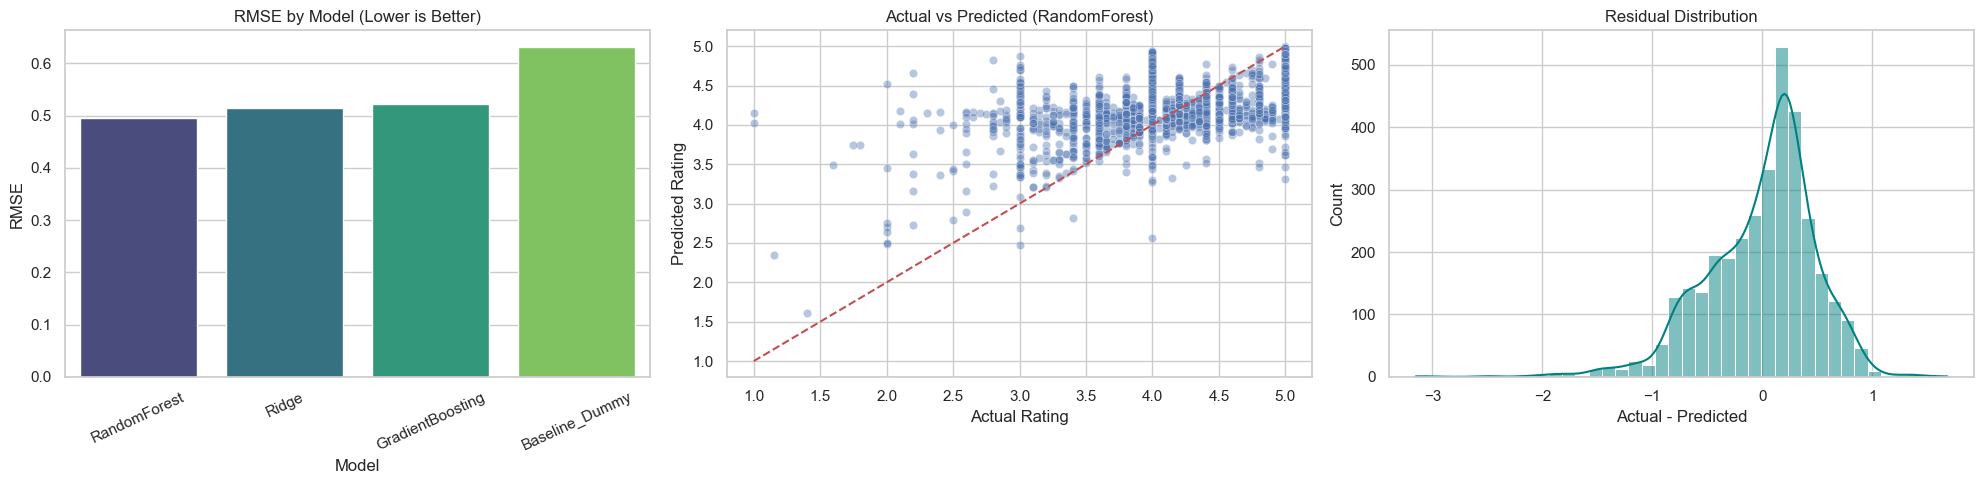

In [8]:
# Regression diagnostics visualizations
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1) Model comparison by RMSE
sns.barplot(data=regression_results_df, x='Model', y='RMSE', ax=axes[0], palette='viridis')
axes[0].set_title('RMSE by Model (Lower is Better)')
axes[0].tick_params(axis='x', rotation=25)

# 2) Actual vs Predicted
sns.scatterplot(x=y_test, y=best_reg_pred, alpha=0.4, ax=axes[1])
line_min = min(y_test.min(), best_reg_pred.min())
line_max = max(y_test.max(), best_reg_pred.max())
axes[1].plot([line_min, line_max], [line_min, line_max], 'r--')
axes[1].set_title(f'Actual vs Predicted ({best_reg_name})')
axes[1].set_xlabel('Actual Rating')
axes[1].set_ylabel('Predicted Rating')

# 3) Residual distribution
residuals = y_test - best_reg_pred
sns.histplot(residuals, bins=40, kde=True, ax=axes[2], color='teal')
axes[2].set_title('Residual Distribution')
axes[2].set_xlabel('Actual - Predicted')

plt.tight_layout()
plt.show()

In [9]:
# 5-fold cross-validation on best regression model
cv_rmse = -cross_val_score(
    best_reg_pipe,
    X, y,
    scoring='neg_root_mean_squared_error',
    cv=5,
    n_jobs=-1
)

print('5-Fold CV RMSE scores:', np.round(cv_rmse, 4))
print('Mean CV RMSE       :', round(cv_rmse.mean(), 4))
print('Std CV RMSE        :', round(cv_rmse.std(), 4))

5-Fold CV RMSE scores: [0.6063 0.5497 0.4954 0.4818 0.5492]
Mean CV RMSE       : 0.5365
Std CV RMSE        : 0.0445


## Part B: Classification Model (Predict rating_category)

This gives a direct **accuracy** metric for presentation.

In [10]:
# Ensure rating category exists
if 'rating_category' not in df.columns:
    def make_bucket(x):
        if x <= 2:
            return 'Low'
        elif x <= 4:
            return 'Medium'
        return 'High'

    df['rating_category'] = df['rating'].apply(make_bucket)

X_cls = X.copy()
y_cls = df.loc[X_cls.index, 'rating_category'].astype(str)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls,
    test_size=0.2,
    random_state=42,
    stratify=y_cls
)

classification_models = {
    'LogisticRegression': LogisticRegression(max_iter=2000),
    'RandomForestClassifier': RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
}

classification_results = []
trained_classification_pipelines = {}

for name, model in classification_models.items():
    clf_pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    clf_pipe.fit(Xc_train, yc_train)
    yc_pred = clf_pipe.predict(Xc_test)

    acc = accuracy_score(yc_test, yc_pred)
    f1w = f1_score(yc_test, yc_pred, average='weighted')

    classification_results.append({
        'Model': name,
        'Accuracy': acc,
        'F1_Weighted': f1w
    })

    trained_classification_pipelines[name] = (clf_pipe, yc_pred)

classification_results_df = pd.DataFrame(classification_results).sort_values('Accuracy', ascending=False).reset_index(drop=True)
display(classification_results_df)

,Model,Accuracy,F1_Weighted
0,RandomForestClassifier,0.710534,0.679773
1,LogisticRegression,0.698570,0.688916


Best classification model: RandomForestClassifier

Classification report:
              precision    recall  f1-score   support

        High       0.70      0.93      0.80      2100
         Low       1.00      0.08      0.14        13
      Medium       0.75      0.37      0.49      1314

    accuracy                           0.71      3427
   macro avg       0.82      0.46      0.48      3427
weighted avg       0.72      0.71      0.68      3427



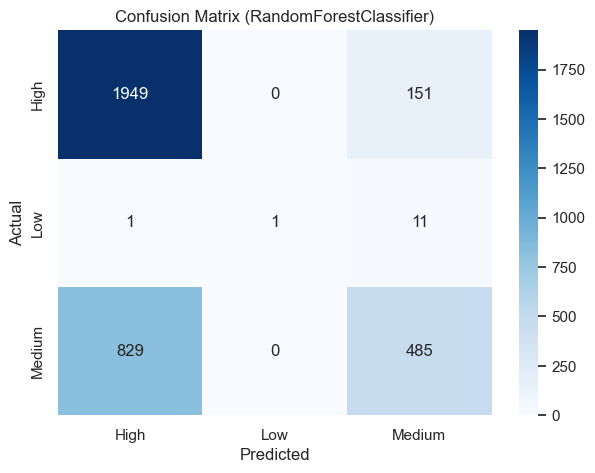

In [11]:
best_cls_name = classification_results_df.loc[0, 'Model']
best_cls_pipe, best_cls_pred = trained_classification_pipelines[best_cls_name]

print('Best classification model:', best_cls_name)
print('\nClassification report:')
print(classification_report(yc_test, best_cls_pred))

labels = sorted(yc_test.unique())
cm = confusion_matrix(yc_test, best_cls_pred, labels=labels)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title(f'Confusion Matrix ({best_cls_name})')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Part C: Visualization (Open-Source Tools)

Below are interactive visualizations built using **Plotly** and static visuals using **Seaborn/Matplotlib**.

In [12]:
# 1) Source-wise average rating + review volume
source_summary = (
    df.groupby('source')
      .agg(avg_rating=('rating', 'mean'), review_count=('review_id', 'count'))
      .reset_index()
)

fig = px.bar(
    source_summary,
    x='source',
    y='avg_rating',
    color='review_count',
    text='review_count',
    title='Average Rating by Source (Color = Review Volume)',
    color_continuous_scale='Viridis'
)
fig.update_layout(xaxis_title='Source', yaxis_title='Average Rating')
fig.show()

In [13]:
# 2) Yearly trend by source
yearly = (
    df.dropna(subset=['year'])
      .groupby(['year', 'source'])['rating']
      .mean()
      .reset_index()
)

fig = px.line(
    yearly,
    x='year',
    y='rating',
    color='source',
    markers=True,
    title='Year-wise Average Rating Trend by Source'
)
fig.update_layout(xaxis_title='Year', yaxis_title='Average Rating')
fig.show()

In [14]:
# 3) Sentiment vs Rating (interactive scatter)
sample_df = df.sample(min(len(df), 5000), random_state=42).copy()

fig = px.scatter(
    sample_df,
    x='sentiment_score',
    y='rating',
    color='source',
    hover_data=['college_name', 'review_length', 'sentiment_label'],
    opacity=0.5,
    title='Sentiment Score vs Rating (Sampled for Performance)'
)
fig.update_layout(xaxis_title='Sentiment Score', yaxis_title='Rating')
fig.show()

In [15]:
# 4) Top 15 colleges by weighted score (confidence-adjusted)
college_perf = (
    df.groupby('college_name')
      .agg(
          avg_rating=('rating', 'mean'),
          review_count=('review_id', 'count')
      )
      .reset_index()
)

global_mean = df['rating'].mean()
m = 30  # minimum review prior strength
college_perf['weighted_score'] = (
    (college_perf['review_count'] / (college_perf['review_count'] + m)) * college_perf['avg_rating']
    + (m / (college_perf['review_count'] + m)) * global_mean
)

top15 = college_perf.sort_values('weighted_score', ascending=False).head(15)

fig = px.bar(
    top15.sort_values('weighted_score'),
    x='weighted_score',
    y='college_name',
    orientation='h',
    color='review_count',
    title='Top 15 Colleges by Confidence-Adjusted Weighted Rating',
    color_continuous_scale='Tealgrn'
)
fig.update_layout(xaxis_title='Weighted Rating', yaxis_title='College')
fig.show()

In [16]:
# 5) Topic mention impact visualization
topic_cols = [c for c in ['placement', 'faculty', 'infrastructure', 'hostel', 'campus'] if c in df.columns]
topic_rows = []

for t in topic_cols:
    yes_mean = df.loc[df[t] == 1, 'rating'].mean()
    no_mean = df.loc[df[t] == 0, 'rating'].mean()
    mentions = int((df[t] == 1).sum())
    topic_rows.append({
        'Topic': t,
        'Mentioned': yes_mean,
        'Not Mentioned': no_mean,
        'Mentions': mentions
    })

topic_df = pd.DataFrame(topic_rows)
topic_melt = topic_df.melt(id_vars=['Topic', 'Mentions'], var_name='Condition', value_name='AvgRating')

fig = px.bar(
    topic_melt,
    x='Topic',
    y='AvgRating',
    color='Condition',
    barmode='group',
    hover_data=['Mentions'],
    title='Impact of Topic Mention on Average Rating'
)
fig.update_layout(yaxis_title='Average Rating')
fig.show()

## Part D: Save Outputs for Viva / Submission

In [17]:
# Save model comparison tables
regression_results_df.to_csv('review2_regression_metrics.csv', index=False)
classification_results_df.to_csv('review2_classification_metrics.csv', index=False)

# Save predictions from best regression model
pred_df = X_test.copy()
pred_df['actual_rating'] = y_test.values
pred_df['predicted_rating'] = best_reg_pred
pred_df['abs_error'] = (pred_df['actual_rating'] - pred_df['predicted_rating']).abs()
pred_df.to_csv('review2_best_model_predictions.csv', index=False)

# Save trained pipelines
joblib.dump(best_reg_pipe, 'review2_best_regression_model.joblib')
joblib.dump(best_cls_pipe, 'review2_best_classification_model.joblib')

print('Saved files:')
print('- review2_regression_metrics.csv')
print('- review2_classification_metrics.csv')
print('- review2_best_model_predictions.csv')
print('- review2_best_regression_model.joblib')
print('- review2_best_classification_model.joblib')

Saved files:
- review2_regression_metrics.csv
- review2_classification_metrics.csv
- review2_best_model_predictions.csv
- review2_best_regression_model.joblib
- review2_best_classification_model.joblib


## What to Highlight During Review 2

1. You built both regression and classification formulations.
2. You compared multiple models against a baseline.
3. You reported MAE/RMSE/R2 plus Accuracy/F1 and confusion matrix.
4. You validated stability with 5-fold cross-validation.
5. You delivered interactive open-source visualizations for decision support.